# Breast Cancer Classification with Logistic Regression

An introduction to **supervised machine learning** using the
[Wisconsin Breast Cancer dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)
(bundled with scikit-learn).

Train a **Logistic Regression** model that predicts whether a tumor is
**malignant (cancerous)** or **benign (non-cancerous)** from 30 measurements
taken from a fine needle aspirate (FNA) of a breast mass.

### In this notebook

- Load and explore a dataset with `pandas` and scikit-learn
- Separate **features (X)** and **labels (y)**
- Split the data into **training** and **testing** sets
- Train a **Logistic Regression** model with `fit()`
- Make predictions with `predict()`
- Evaluate the model using the **confusion matrix**, **accuracy**,
  **precision**, **recall**, and **F1 score**


## 1. Setup and Imports

Import the libraries used in this notebook:

- `numpy` / `pandas` — for working with numbers and tabular data
- `matplotlib.pyplot` — for simple visualizations
- scikit-learn (`sklearn`) — provides the dataset, the model, and the
  evaluation metrics


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

## 2. Dataset

`load_breast_cancer()` returns a **Bunch** object — a dictionary-like container.
The most important parts are:

| Attribute          | Contains                                                                  |
|--------------------|---------------------------------------------------------------------------|
| `data`             | A 2D array of **30 features**, one row per patient (569 patients)         |
| `target`           | The **label** for each patient: `0` = malignant, `1` = benign             |
| `feature_names`    | The names of the 30 features                                              |
| `target_names`     | The names of the two classes (`malignant`, `benign`)                      |
| `DESCR`            | A full written description of the dataset                                 |

Load the dataset and take a quick look at the labels.


In [2]:
# Load the dataset (returns a Bunch object)
data = load_breast_cancer()

# Each sample is labeled 0 (malignant) or 1 (benign)
print(data.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

The raw `data` array is not very easy to read, so wrap it in a **pandas
DataFrame** — a table with named columns — using the feature names.


In [3]:
# Build a DataFrame from the features, using the feature names as columns
df = pd.DataFrame(data.data, columns=data.feature_names)

# Show the first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Add the label as a column so everything lives in one table
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Data Exploration

Check how many samples belong to each class. This reveals whether the dataset
is **balanced** (roughly equal classes) or **imbalanced**.


In [5]:
# Count how many samples fall into each class
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

There are 357 benign and 212 malignant samples — the classes are slightly
imbalanced but reasonably close. View the same information as a bar chart.


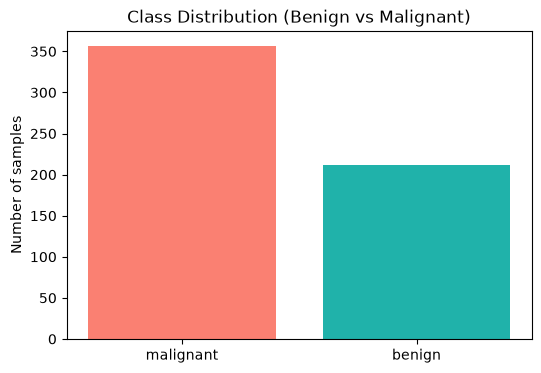

In [6]:
# Bar chart of the class distribution
class_counts = df["target"].value_counts()
labels = data.target_names  # ["malignant", "benign"]

plt.figure(figsize=(6, 4))
plt.bar(labels, class_counts, color=["salmon", "lightseagreen"])
plt.ylabel("Number of samples")
plt.title("Class Distribution (Benign vs Malignant)")
plt.show()

## 4. Features (X) and Labels (y)

Separate the data into two pieces before training:

- **X (features)** — the 30 measurements used to make a prediction
- **y (labels / target)** — the answer the model should predict

| Variable | Shape       | Contains                       |
|----------|-------------|--------------------------------|
| `X`      | 569 × 30    | 30 features for 569 patients   |
| `y`      | (569,)      | 1 label for each patient       |


In [7]:
# Features: everything except the target column
X = df.drop("target", axis=1)

# Labels: only the target column
y = df["target"]

print(f"X shape: {X.shape}")  # 569 rows (patients) x 30 columns (features)
print(f"y shape: {y.shape}")  # 569 labels

X shape: (569, 30)
y shape: (569,)


## 5. Train/Test Split

Hold out **20% of the data as a test set**. The model never sees the test
set during training, so it shows how well the model generalizes to new,
unseen patients.

- `X_train`, `y_train` — used to **teach** the model
- `X_test`, `y_test` — used to **evaluate** the model

A fixed `random_state` makes the split reproducible: run it again and you get
the exact same split.


In [8]:
# Split into 80% training / 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 455
Test samples:     114


## 6. Model Training (Logistic Regression)

**Logistic Regression** is a simple but powerful classification algorithm. It
finds a line (or plane, in higher dimensions) that best separates the two
classes by learning a **weight** for every feature.

- `model.fit(X_train, y_train)` — the **training** step: the model learns the
  weights from the training data.

In [9]:
# Create the model (max_iter is raised so the optimizer converges)
model = LogisticRegression(max_iter=10000)

# Train the model on the training data
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

## 7. Predictions

- `model.predict(X_test)` — the **inference** step: the model uses the learned
  weights to predict a label (0 or 1) for each test sample.

Store the predictions in `y_pred` and use them for evaluation below.


In [10]:
# Predict labels for the unseen test set
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 1 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 0 1
 1 0 0 1 1 1 1 1 0 1 1 0 1 1 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 1 1 0 0
 1 1 0]


## 8. Evaluation Metrics

Compare the model's predictions (`y_pred`) against the true labels
(`y_test`).

### 8.1 Accuracy

**Accuracy** is the fraction of correct predictions out of all predictions:

$$\text{Accuracy} = \frac{\text{Correct predictions}}{\text{Total predictions}}$$

It is the most intuitive metric, but it can be misleading on imbalanced data
or when certain mistakes are more costly than others.


In [11]:
# Fraction of predictions the model got right
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 92.98%


### 8.2 Confusion Matrix

The confusion matrix compares **predicted** vs **actual** labels for every
sample. In this notebook the **positive class is `1` (benign)**.

|                      | Predicted 0 (malignant) | Predicted 1 (benign) |
|----------------------|-------------------------|----------------------|
| **Actual 0 (malignant)** | True Negative (TN)   | False Positive (FP)  |
| **Actual 1 (benign)**    | False Negative (FN)  | True Positive (TP)   |

In [12]:
# 2x2 table: rows = actual, columns = predicted
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[48  6]
 [ 2 58]]


Read the four numbers from this matrix:

- **48 True Negatives** — actually malignant, predicted malignant
- **6 False Positives** — actually malignant, but predicted benign
- **2 False Negatives** — actually benign, but predicted malignant
- **58 True Positives** — actually benign, predicted benign

The same matrix as a heatmap:


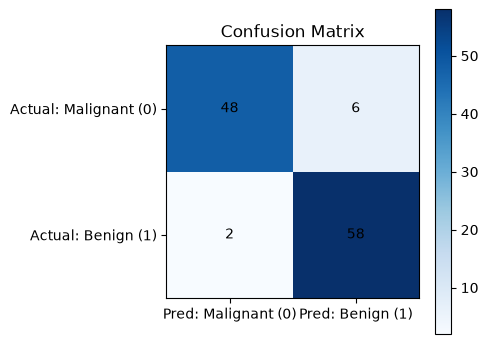

In [13]:
# Visualize the confusion matrix as a simple heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

# Write the counts inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred: Malignant (0)", "Pred: Benign (1)"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual: Malignant (0)", "Actual: Benign (1)"])
ax.set_title("Confusion Matrix")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 8.3 Precision

**Precision** answers: *of all the samples labeled positive, how many were
actually positive?*

$$\text{Precision} = \frac{TP}{TP + FP} = \frac{58}{58 + 6} = 90.6\%$$

In this project, precision tells us: **when the model says a tumor is benign,
how often is it right?** Verify the sklearn value with a manual calculation
from the confusion matrix.


In [14]:
precision = precision_score(y_test, y_pred)
print(f"Precision (sklearn): {precision * 100:.2f}%")

# Manual calculation: TP / (TP + FP)
manual_precision = cm[1][1] / (cm[0][1] + cm[1][1])
print(f"Precision (manual):  {manual_precision * 100:.3f}%")

Precision (sklearn): 90.62%
Precision (manual):  90.625%


### 8.4 Recall (Sensitivity)

**Recall** answers: *of all the samples that were actually positive, how many
did the model catch?*

$$\text{Recall} = \frac{TP}{TP + FN} = \frac{58}{58 + 2} = 96.7\%$$

In this project, recall tells us: **of all truly benign tumors, how many did
the model find?** Recall is especially important in medicine, because missing
a positive case (a False Negative) can have serious consequences.


In [15]:
recall = recall_score(y_test, y_pred)
print(f"Recall (sklearn): {recall * 100:.2f}%")

# Manual calculation: TP / (TP + FN)
manual_recall = cm[1][1] / (cm[1][0] + cm[1][1])
print(f"Recall (manual):  {manual_recall * 100:.3f}%")

Recall (sklearn): 96.67%
Recall (manual):  96.667%


### 8.5 F1 Score

**F1 score** is the harmonic mean of precision and recall. It gives a single
number that balances both, which is useful when you care about both false
positives and false negatives.

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [16]:
f1 = f1_score(y_test, y_pred)
print(f"F1 (sklearn): {f1 * 100:.2f}%")

# Manual calculation: harmonic mean of precision and recall
manual_f1 = 2 * (precision * recall) / (precision + recall)
print(f"F1 (manual):  {manual_f1 * 100:.2f}%")

F1 (sklearn): 93.55%
F1 (manual):  93.55%


### 8.6 Classification Report

`classification_report` prints precision, recall, and F1 for **every** class in
a single table. The `support` column shows how many true samples of each class
were in the test set.

- `macro avg` — the unweighted average across both classes
- `weighted avg` — the average weighted by each class's support

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92        54
           1       0.91      0.97      0.94        60

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



## 9. Conclusion

The Logistic Regression model achieved **92.98% accuracy** on the unseen test
set, with:

| Metric     | Value   |
|------------|---------|
| Accuracy   | 92.98%  |
| Precision  | 90.62%  |
| Recall     | 96.67%  |
| F1 Score   | 93.55%  |

Breaking down the confusion matrix:

- **106 / 114** test samples were classified correctly (48 + 58)
- **8 / 114** were misclassified (6 + 2)

A key takeaway: **accuracy alone is not enough**. In medical screening, a
False Negative (missing a disease) is far more dangerous than a False
Positive (raising a false alarm). That is why precision, recall, and the F1
score also matter — each metric tells a different part of the story.

### Next steps

- Try scaling the features with `StandardScaler` and compare the results.
- Try other classifiers, such as `RandomForestClassifier` or `SVC`.
- Plot an **ROC curve** and compute the **AUC** for an even richer picture of
  model performance.
